<a href="https://colab.research.google.com/github/sparsetrace/DNDR/blob/main/IDUMAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os, sys, subprocess as sbp
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
os.environ["PIP_DISABLE_PIP_VERSION_CHECK"] = "1"
try:
    from dmae import DMAE, DMAP, GPLM
    from dmae.plot_helper import compare_3d_plots
except:
    sbp.check_call([sys.executable, "-m", "pip", "install", "git+https://github.com/sparsetrace/DMAE.git"])
    from dmae import DMAE, DMAP, GPLM
    from dmae.plot_helper import compare_3d_plots
try:
    import dndr
except:
    sbp.check_call([sys.executable, "-m", "pip", "install", "git+https://github.com/sparsetrace/DNDR.git"])
    import dndr

# Swiss Roll

## Isometric swiss roll: flat sheet to rolled sheet

Let the flat sheet coordinates be $(s,h)\in[0,W]\times[0,H]$.

Let the spiral cross-section be an Archimedean spiral
$$
r(\theta)=r_0+b\theta,\qquad b>0.
$$

The rolled sheet is obtained by bending the sheet around the $y$-axis:
$$
x=r(\theta)\cos\theta,\qquad y=h,\qquad z=r(\theta)\sin\theta.
$$

To make this an **isometric** roll, the flat horizontal coordinate $s$ must equal the arc length along the spiral from $\theta_{\min}$ to $\theta$:
$$
s=\int_{\theta_{\min}}^{\theta}\sqrt{r(\tau)^2+\left(\frac{dr}{d\tau}\right)^2}\,d\tau.
$$

Since $r(\tau)=r_0+b\tau$ and $\frac{dr}{d\tau}=b$, this becomes
$$
s=\int_{\theta_{\min}}^{\theta}\sqrt{(r_0+b\tau)^2+b^2}\,d\tau.
$$

Define
$$
S(\theta)=
\frac{
u\sqrt{u^2+b^2}
+
b^2\,\operatorname{asinh}(u/b)
}{2b},
\qquad
u=r_0+b\theta.
$$

Then
$$
s=S(\theta)-S(\theta_{\min}).
$$

So the forward map is
$$
\theta=S^{-1}\!\bigl(S(\theta_{\min})+s\bigr),
$$
$$
r=r_0+b\theta,
$$
$$
x=r\cos\theta,\qquad y=h,\qquad z=r\sin\theta.
$$

Thus,
$$
(s,h)\mapsto (x,y,z).
$$

In [2]:
from dndr.swiss_roll import swiss_roll

# Example:
roll_map, E_ix, E_iX, SH_back, color = swiss_roll(
    width=60.0,   # this is the literal unrolled sheet length
    height=10.0,  # literal sheet height
    r0=0.5, b=0.6, n_points=4000, seed=1, plot=True
)

E_ix.shape, E_iX.shape, color.shape

sheet size: (60.0, 10.0)
theta range: (4.71238898038469, 14.324273623150017)
max round-trip error: 7.682572800149501e-09
mean round-trip error: 2.5741361059927746e-09


((4000, 2), (4000, 3), (4000,))

# IMAP, DMAP, and UMAP

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from dndr.solvers import scan_precomputed_dmap_to_target, scan_isomap_to_target, scan_umap_to_target

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------
ds = np.array([1, 2, 3, 4, 5, 6, 7, 8, 16, 32, 64, 128, 256, 512, 1024])
dims_to_show = [1, 2, 8, 1024]

# ------------------------------------------------------------
# Run all three scans
# ------------------------------------------------------------
print("IMAP")
result_imap = scan_isomap_to_target(
    R_iX=E_iX,
    Q_ix=E_ix,
    ds=ds,
    isomap_n_neighbors=12,
    fit_intercept=True,
    normalize_target=True,
    normalize_source=True,
    method="lstsq",
    ridge=1e-6,
)

print("DMAP")
d_max = int(ds.max())
encoder = DMAP(E_iX, d=d_max, h=1, beta=0.5) ## solve it once
R_in_max = encoder(E_iX)[:, 0, :]   # shape (N, d_max)
result_dmap = scan_precomputed_dmap_to_target(
    R_in_max=R_in_max,
    Q_ix=E_ix,
    ds=ds,
    fit_intercept=True,
    normalize_target=True,
    normalize_source=True,
    method="lstsq",
    ridge=1e-6,
)

print("UMAP")
result_umap = scan_umap_to_target(
    R_iX=E_iX,
    Q_ix=E_ix,
    ds=ds,
    umap_n_neighbors=30,
    umap_min_dist=0.05,
    umap_metric="euclidean",
    fit_intercept=True,
    normalize_target=True,
    normalize_source=True,
    method="lstsq",
    ridge=1e-6,
    base_random_state=42,
)

d=  1 | target_dim= 2 | L shape=(2, 2) | MSE=3.360160e-06 | relF=0.163955
d=  2 | target_dim= 2 | L shape=(3, 2) | MSE=2.172505e-08 | relF=0.013183
d=  3 | target_dim= 2 | L shape=(4, 2) | MSE=1.976694e-08 | relF=0.012575
d=  4 | target_dim= 2 | L shape=(5, 2) | MSE=1.952434e-08 | relF=0.012498
d=  5 | target_dim= 2 | L shape=(6, 2) | MSE=1.860428e-08 | relF=0.012200
d=  6 | target_dim= 2 | L shape=(7, 2) | MSE=1.789070e-08 | relF=0.011964
d=  7 | target_dim= 2 | L shape=(8, 2) | MSE=1.756069e-08 | relF=0.011853
d=  8 | target_dim= 2 | L shape=(9, 2) | MSE=1.754997e-08 | relF=0.011849
d= 16 | target_dim= 2 | L shape=(17, 2) | MSE=1.477409e-08 | relF=0.010872
d= 32 | target_dim= 2 | L shape=(33, 2) | MSE=1.308889e-08 | relF=0.010233
d= 64 | target_dim= 2 | L shape=(65, 2) | MSE=1.112739e-08 | relF=0.009435
d=128 | target_dim= 2 | L shape=(129, 2) | MSE=9.942296e-09 | relF=0.008918
d=256 | target_dim= 2 | L shape=(257, 2) | MSE=9.064191e-09 | relF=0.008515
d=512 | target_dim= 2 | L shape

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



d=  1 | target_dim= 2 | L shape=(2, 2) | MSE=4.126256e-06 | relF=0.181687


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



d=  2 | target_dim= 2 | L shape=(3, 2) | MSE=1.200532e-05 | relF=0.309907


...

d=256 | target_dim= 2 | L shape=(257, 2) | MSE=3.966928e-08 | relF=0.017814


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



d=512 | target_dim= 2 | L shape=(513, 2) | MSE=2.892165e-08 | relF=0.015211


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



d=1024 | target_dim= 2 | L shape=(1025, 2) | MSE=2.073230e-08 | relF=0.012879


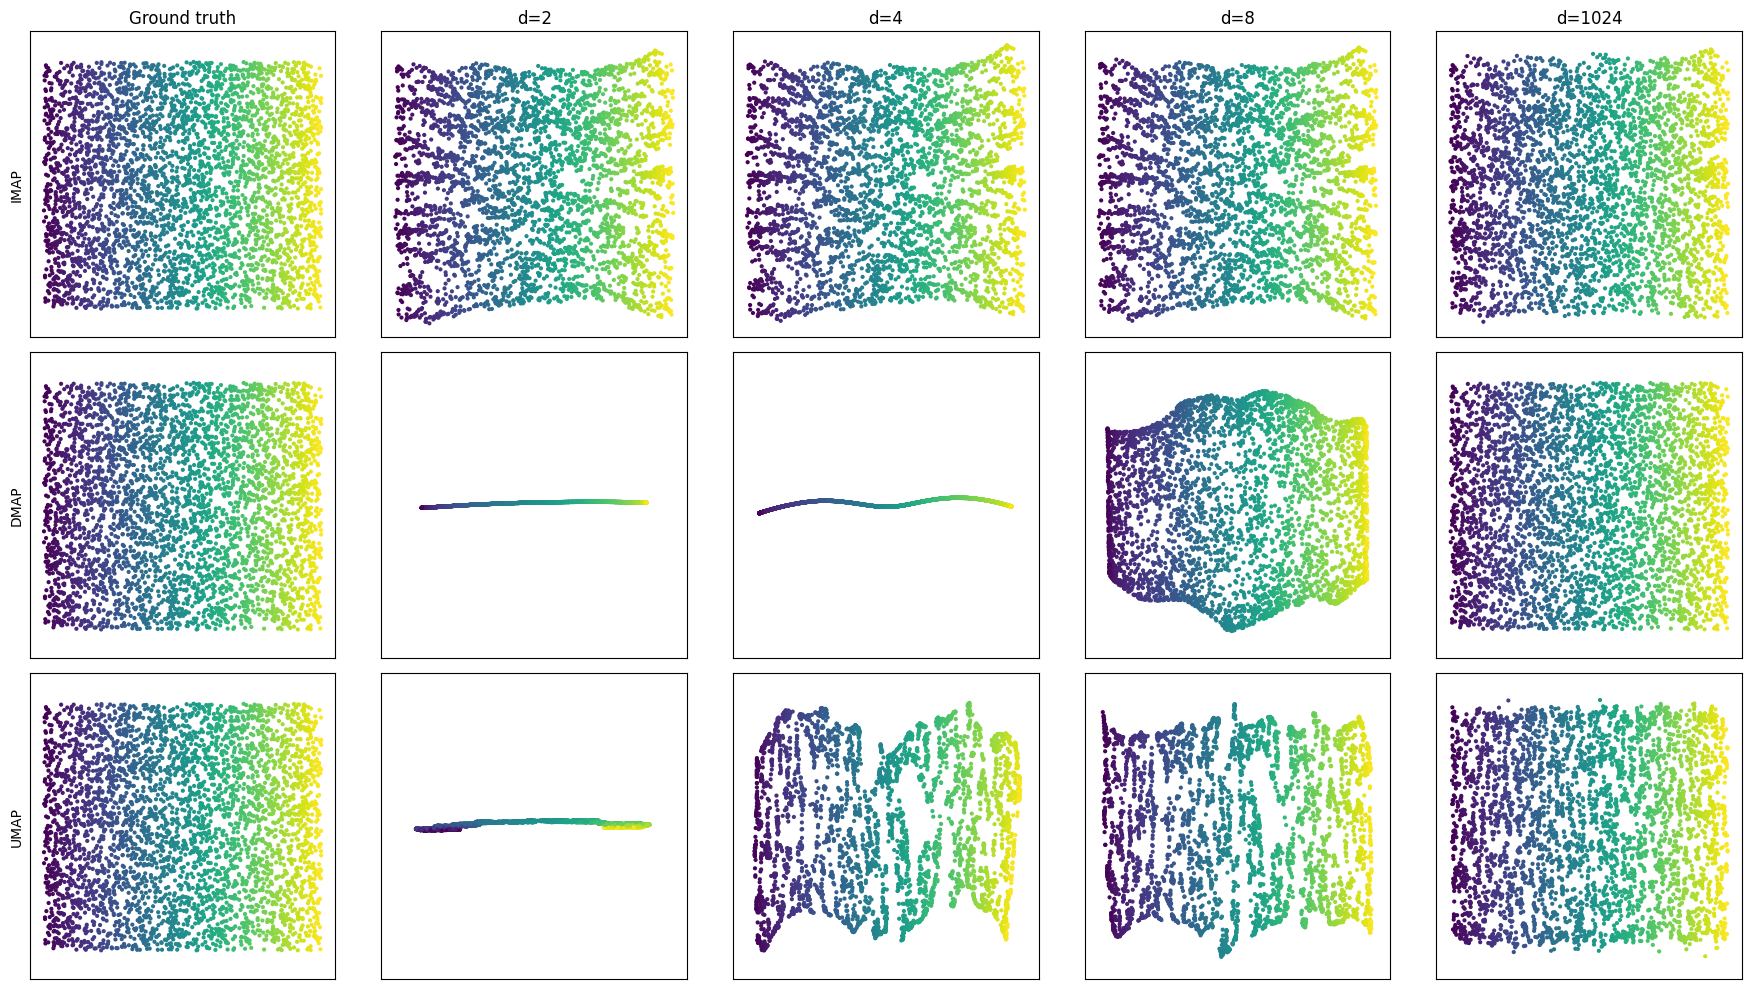

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def get_reconstruction_at_d(result, d):
    ds_result = np.asarray(result["ds"])
    s = int(np.where(ds_result == d)[0][0])
    return result["R_six"][s], s

method_results = [
    ("IMAP", result_imap),
    ("DMAP", result_dmap),
    ("UMAP", result_umap),
]

dims_to_show = [2, 4, 8, 1024]

# ------------------------------------------------------------
# Compute common limits across everything shown
# ------------------------------------------------------------
all_xy = []

for method_name, result in method_results:
    all_xy.append(result["Q_use"])  # ground truth
    for d in dims_to_show:
        Qhat, _ = get_reconstruction_at_d(result, d)
        all_xy.append(Qhat)

all_xy = np.vstack(all_xy)

xmin, ymin = all_xy.min(axis=0)
xmax, ymax = all_xy.max(axis=0)

# add a small margin
pad_x = 0.05 * (xmax - xmin if xmax > xmin else 1.0)
pad_y = 0.05 * (ymax - ymin if ymax > ymin else 1.0)

xlim = (xmin - pad_x, xmax + pad_x)
ylim = (ymin - pad_y, ymax + pad_y)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, axes = plt.subplots(3, 5, figsize=(18, 10), squeeze=False)

scatter_kwargs = dict(s=4)
if "color" in globals() and color is not None:
    scatter_kwargs["c"] = color

for row, (method_name, result) in enumerate(method_results):
    Q_use = result["Q_use"]

    # col 0: ground truth
    ax = axes[row, 0]
    ax.scatter(Q_use[:, 0], Q_use[:, 1], **scatter_kwargs)
    if row == 0:
        ax.set_title("Ground truth")
    ax.set_ylabel(method_name)

    # cols 1..4: reconstructions
    for col, d in enumerate(dims_to_show, start=1):
        Qhat, _ = get_reconstruction_at_d(result, d)
        ax = axes[row, col]
        ax.scatter(Qhat[:, 0], Qhat[:, 1], **scatter_kwargs)
        if row == 0:
            ax.set_title(f"d={d}")

# force same box shape + same limits everywhere
for ax in axes.ravel():
    ax.set_box_aspect(1)   # square subplot box
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.savefig("IDU.png", dpi=300, bbox_inches="tight")
plt.show()

Ground-truth sheet and affine reconstructions from IMAP, DMAP, and UMAP as the latent dimension $d$ increases. IMAP produces the correct sheet at small $d$, DMAP initially collapses to low-dimensional spectral modes before recovering the sheet at large $d$, and UMAP transitions between these behaviors.

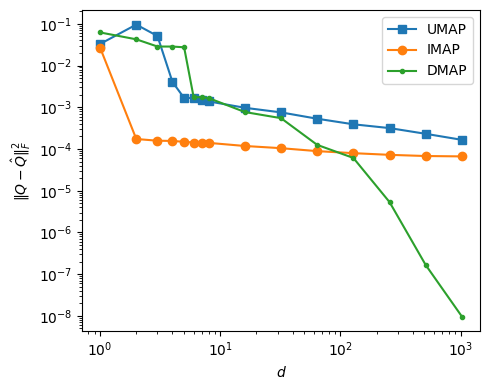

In [19]:
import numpy as np
import matplotlib.pyplot as plt

def fro2_from_result(result):
    """
    Compute ||Q - Qhat||_F^2 for each scanned d from a scan result dict.
    """
    Q_use = result["Q_use"]                      # shape (N, x)
    R_six = np.stack(result["R_six"], axis=0)   # shape (S, N, x)

    mse_s = np.mean((R_six - Q_use[None, :, :])**2, axis=(1, 2))
    N, x = Q_use.shape
    fro2_s = mse_s * (N * x)
    return fro2_s

fro2_umap_s = fro2_from_result(result_umap)
fro2_imap_s = fro2_from_result(result_imap)
fro2_dmap_s = fro2_from_result(result_dmap)

plt.figure(figsize=(5, 4))
plt.plot(result_umap["ds"], fro2_umap_s, marker="s", label="UMAP")
plt.plot(result_imap["ds"], fro2_imap_s, marker="o", label="IMAP")
plt.plot(result_dmap["ds"], fro2_dmap_s, marker=".", label="DMAP")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("$d$")
plt.ylabel(r"$\|Q-\hat Q\|_F^2$")
plt.legend()
plt.tight_layout()
plt.savefig("error.png", dpi=300, bbox_inches="tight")
plt.show()

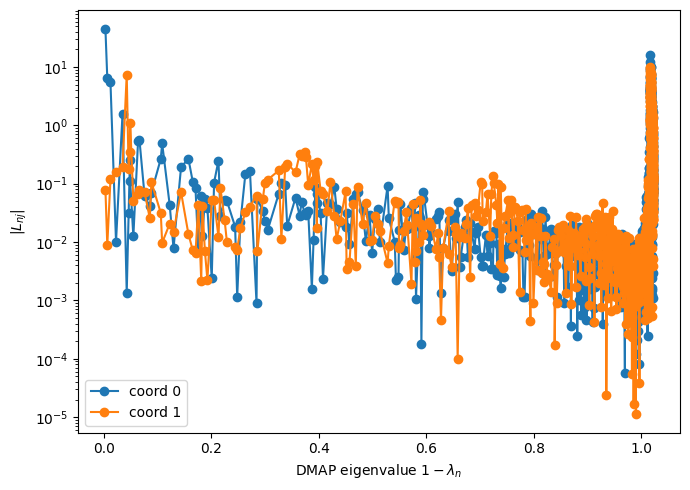

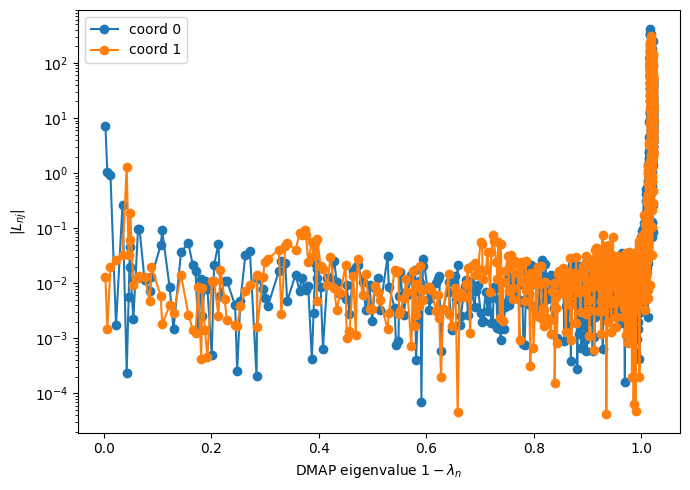

In [21]:
from dndr.plot_helper import plot_dmap_spectra_overlay

s_best=-1
d = ds[s_best]
L_nx = result_dmap["L_s"][s_best][:-1,:]   # fitted map for that d
lambdas_full = encoder.init_data.λ_x[0]
U_in = result_dmap["U_sin"][s_best]

A_nx = np.linalg.norm(U_in, axis=0)[:, None] * np.abs(L_nx)

plot_dmap_spectra_overlay(A_nx, 1-lambdas_full[:d], xscale=None)


plot_dmap_spectra_overlay(L_nx, 1-lambdas_full[:d], xscale=None)


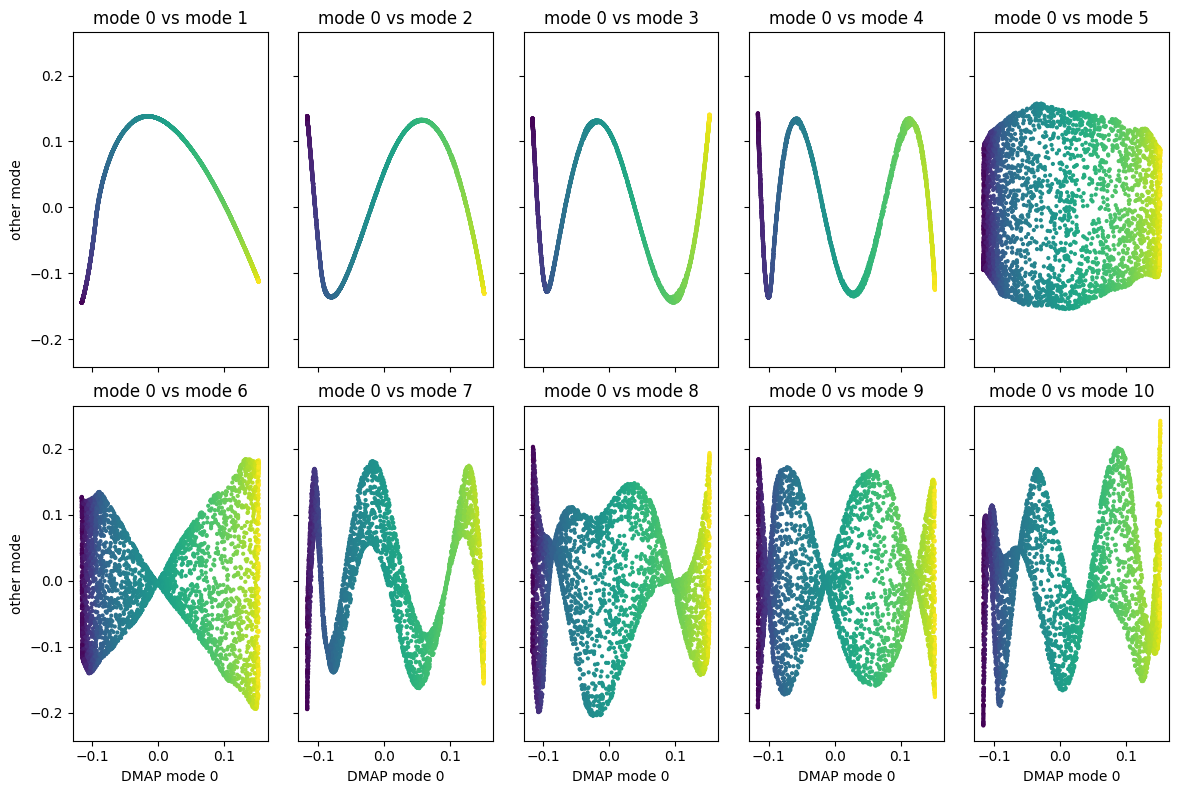

In [8]:
modes_to_compare = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

fig, axes = plt.subplots(2, 5, figsize=(12, 8), sharex=True, sharey=True, squeeze=False)
axes = axes.ravel()

for ax, m in zip(axes, modes_to_compare):
    U_2 = R_in_max[:, [0, m]]
    ax.scatter(U_2[:, 0], U_2[:, 1], s=4, c=color)
    ax.set_title(f"mode 0 vs mode {m}")
    ax.set_aspect("equal", adjustable="box")

for ax in axes[5:]:
    ax.set_xlabel("DMAP mode 0")
for ax in axes[::5]:
    ax.set_ylabel("other mode")

plt.tight_layout()
plt.savefig("sheets.png", dpi=300, bbox_inches="tight")
plt.show()